Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pytensor.tensor as pt
import pymc as pm
from scipy.stats import norm
from pathlib import Path
from utils import extract_psychometric, cumulative_normal

plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
hrd_path = Path.cwd().parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
hrd_df = hrd_df[hrd_df.task == "hrd-session2"]

In [3]:
one_participant_df = hrd_df[
    (hrd_df.participant_id == "sub-0019") & (hrd_df.Modality == "Intero")
]

# Cardiac beliefs

In [4]:
# split the dataset into subject-wise low, medium and high cardiac frequencies
lowBPM_df, mediumBPM_df, highBPM_df = (
    pd.DataFrame([]),
    pd.DataFrame([]),
    pd.DataFrame([]),
)
for sub in hrd_df.participant_id.unique():
    this_df = hrd_df[(hrd_df.participant_id == sub) & (hrd_df.Modality == "Intero")]

    first, second = this_df.listenBPM.quantile(0.33), this_df.listenBPM.quantile(0.66)

    lowBPM_df = pd.concat([lowBPM_df, this_df[this_df.listenBPM <= first]])
    mediumBPM_df = pd.concat(
        [
            mediumBPM_df,
            this_df[(this_df.listenBPM > first) & (this_df.listenBPM <= second)],
        ]
    )
    highBPM_df = pd.concat([highBPM_df, this_df[this_df.listenBPM > second]])

In [ ]:
with pm.Model() as psychopysics:
    # heart rate -----------------------------------------------------
    sigma_hr = pm.Uniform("sigma_hr", 0.1, 30.0, shape=nsub)
    mean_hr = pm.Uniform("mean_hr", lower=15, upper=200, shape=nsub)
    heart_rate = pm.Normal(
        "heart_rate",
        mu=mean_hr[idx_hr],
        sigma=sigma_hr[idx_hr],
        observed=heart_rate,
    )

    threshold = pm.Uniform("threshold", lower=15, upper=160, shape=nsub)
    slope = pm.Uniform("slope", lower=0.1, upper=20, shape=nsub)

    thetaij = pm.Deterministic(
        "thetaij", cumulative_normal(x_total, 50.0, slope[sub_total])
    )

    rij_ = pm.Binomial("rij", p=thetaij, n=n_total, observed=r_total)

    idata = pm.sample(
        chains=4, cores=4, tune=1000, draws=1000, return_inferencedata=True
    )

In [9]:
def fit_psychophysics(df: pd.DataFrame):
    """Extract and fit psychophysics functions."""
    nsub = df.participant_id.nunique()

    # Format psychophysics data
    x_total, n_total, r_total, sub_total, cond_total, heart_rate, idx_hr = (
        [],
        [],
        [],
        [],
        [],
        [],
        [],
    )
    for i, sub in enumerate(df.participant_id.unique()):
        sub_df = df[df.participant_id == sub].copy()
        decisionBPM = sub_df.responseBPM.to_numpy()
        decision = (sub_df.Decision.to_numpy() == "More").astype(int)

        heart_rate.extend(sub_df.listenBPM.to_numpy())
        idx_hr.extend([i] * len(sub_df.listenBPM.to_numpy()))

        xij, nij, rij = extract_psychometric(decisionBPM, decision)

        sub_vec = [i] * len(xij)
        x_total.extend(xij)
        n_total.extend(nij)
        r_total.extend(rij)
        sub_total.extend(sub_vec)

    x_total = np.array(x_total)
    n_total = np.array(n_total)
    r_total = np.array(r_total)
    sub_total = np.array(sub_total)
    heart_rate = np.array(heart_rate)

    # Fit Bayesian model
    with pm.Model() as psychopysics:
        # heart rate

        sigma_hr = pm.Uniform("sigma_hr", 0.1, 30.0, shape=nsub)
        mean_hr = pm.Uniform("mean_hr", lower=15, upper=200, shape=nsub)
        heart_rate = pm.Normal(
            "heart_rate",
            mu=mean_hr[idx_hr],
            sigma=sigma_hr[idx_hr],
            observed=heart_rate,
        )

        threshold = pm.Uniform("threshold", lower=15, upper=160, shape=nsub)
        slope = pm.Uniform("slope", lower=0.1, upper=20, shape=nsub)

        thetaij = pm.Deterministic(
            "thetaij", cumulative_normal(x_total, 50.0, slope[sub_total])
        )

        rij_ = pm.Binomial("rij", p=thetaij, n=n_total, observed=r_total)

        idata = pm.sample(
            chains=4, cores=4, tune=1000, draws=1000, return_inferencedata=True
        )

    return idata

In [10]:
idata_low = fit_psychophysics(lowBPM_df)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_hr, mean_hr, threshold, slope]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.


In [11]:
idata_medium = fit_psychophysics(mediumBPM_df)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_hr, mean_hr, threshold, slope]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.


In [12]:
idata_high = fit_psychophysics(highBPM_df)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_hr, mean_hr, threshold, slope]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 44 seconds.


/home/nicolas/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (192) in plot_posterior, generating only 40 plots
  warnings.warn(


[(62.0, 72.0)]

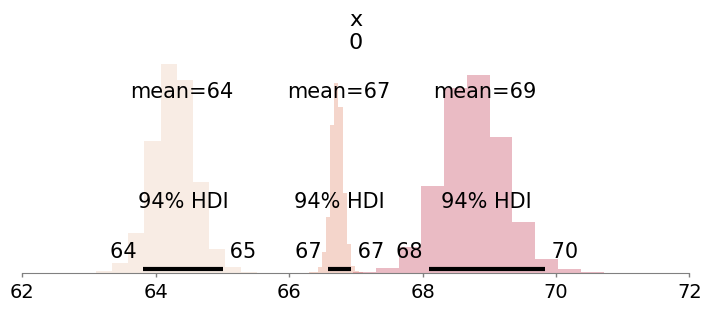

In [13]:
_, axs = plt.subplots(figsize=(7, 3))

for idata, color in zip(
    [idata_low, idata_medium, idata_high], ["#edcbb4", "#e0876a", "#c33e56"]
):
    posterior = (idata.posterior["mean_hr"]).values
    az.plot_posterior(posterior, kind="hist", ax=axs, color=color)
axs.set(xlim=(62, 72))

One way to look at that problem is through the lens of Bayesian filtering. One could represents cardiac beliefs as a distribution informed both by priors and afferent interoceptive signals. But the strength of this later influence can vary, and we have at one extreme the so called "cardiac believers" that would mostly listen to their intuition or prior knowledge when asked to estimate their current heart rate. On the other side, "interoceptors" are the participants ables to use afferent signal to update their belief dynamically. 

## Scatterplots

Another way to look at this problem is by plotting the decisions of the participant as a function of both the actual heart rate (x-axis) and the frequency of the tone (y-axis). The color scales are representing the probability of answering "Faster" at the end of the trial.

In [14]:
one_participant_df = hrd_df[
    (hrd_df.participant_id == "sub-0019") & (hrd_df.Modality == "Intero")
]

In [15]:
n_trials = 200
heart_rates = np.linspace(20, 150, n_trials)
listening_tones = np.linspace(20, 150, n_trials)
deciding_tones = np.linspace(20, 150, n_trials)

In [20]:
def decision(
    listening_tone,
    deciding_tone,
    alpha: float = 0.0,
    beta: float = 1.0,
    perceptual_noise: float = 3.0,
):
    """Produce decision from a linear function of reference tones."""
    threshold = beta * listening_tone + alpha

    return norm.cdf(deciding_tone, loc=threshold, scale=perceptual_noise)

In [21]:
interoceptor_decisions_probs = np.array(
    [
        decision(
            listening_tone, deciding_tone, alpha=0.0, beta=1.0, perceptual_noise=10.0
        )
        for listening_tone in listening_tones
        for deciding_tone in deciding_tones
    ]
).reshape((n_trials, n_trials))

believer_decisions_probs = np.array(
    [
        decision(
            listening_tone, deciding_tone, alpha=60.0, beta=0.0, perceptual_noise=10.0
        )
        for listening_tone in listening_tones
        for deciding_tone in deciding_tones
    ]
).reshape((n_trials, n_trials))

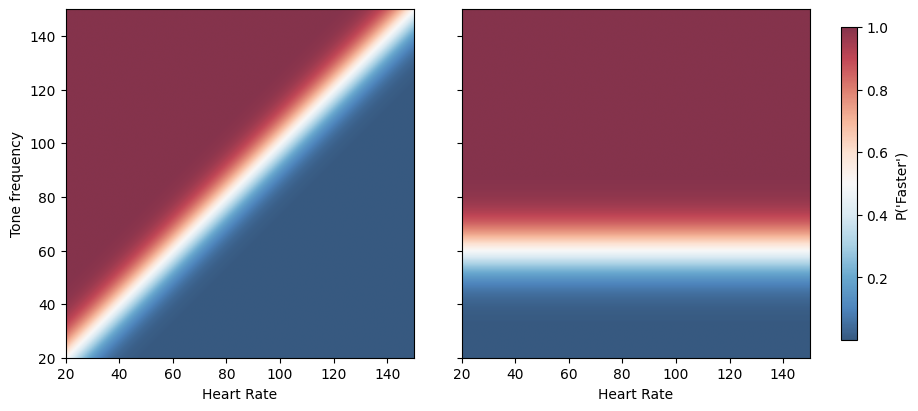

In [49]:
fig, axs = plt.subplots(ncols=2, figsize=(9, 4), sharex=True, sharey=True)

axs[0].imshow(
    interoceptor_decisions_probs.T,
    origin="lower",
    extent=(20.0, 150.0, 20.0, 150.0),
    cmap="RdBu_r",
    interpolation="gaussian",
    alpha=0.8,
)

im = axs[1].imshow(
    believer_decisions_probs.T,
    origin="lower",
    extent=(20.0, 150.0, 20.0, 150.0),
    cmap="RdBu_r",
    interpolation="gaussian",
    alpha=0.8,
)

axs[0].set(xlabel="Heart Rate", ylabel="Tone frequency")
axs[1].set(xlabel="Heart Rate")

# Add a colorbar spanning all subplots
cbar = fig.colorbar(im, ax=axs, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label("P('Faster')")

In [23]:
def fit_psychophysics(df: pd.DataFrame):
    """Fit psychophysics function as a linear function of tone reference."""
    listenBPM = df.listenBPM.to_numpy()
    decisionBPM = df.responseBPM.to_numpy()
    decision = (df.Decision.to_numpy() == "More").astype(int)

    # Fit Bayesian model
    with pm.Model() as psychopysics:
        alpha = pm.Normal("alpha", mu=0.0, sigma=10.0)
        beta = pm.Beta("beta", 1.0, 1.0)
        slope = pm.HalfNormal("slope", 10.0)

        thetaij = pm.Deterministic(
            "thetaij", cumulative_normal(decisionBPM, alpha + beta * listenBPM, slope)
        )

        rij_ = pm.Binomial("rij", p=thetaij, n=1, observed=decision)

        idata = pm.sample(
            chains=4, cores=4, tune=1000, draws=1000, return_inferencedata=True
        )

    return idata

In [24]:
df = hrd_df[(hrd_df.participant_id == "sub-0049") & (hrd_df.Modality == "Extero")]
idata_extero = fit_psychophysics(df)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, slope]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


In [25]:
df = hrd_df[(hrd_df.participant_id == "sub-0049") & (hrd_df.Modality == "Intero")]
idata_intero = fit_psychophysics(df)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, slope]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There were 24 divergences after tuning. Increase `target_accept` or reparameterize.


In [26]:
alpha = az.summary(idata_extero)["mean"]["alpha"]
slope = az.summary(idata_extero)["mean"]["slope"]
beta = az.summary(idata_extero)["mean"]["beta"]

extero_decisions_probs = np.array(
    [
        decision(
            listening_tone,
            deciding_tone,
            alpha=alpha,
            beta=beta,
            perceptual_noise=slope,
        )
        for listening_tone in listening_tones
        for deciding_tone in deciding_tones
    ]
).reshape((n_trials, n_trials))

alpha = az.summary(idata_intero)["mean"]["alpha"]
slope = az.summary(idata_intero)["mean"]["slope"]
beta = az.summary(idata_intero)["mean"]["beta"]

intero_decisions_probs = np.array(
    [
        decision(
            listening_tone,
            deciding_tone,
            alpha=alpha,
            beta=beta,
            perceptual_noise=slope,
        )
        for listening_tone in listening_tones
        for deciding_tone in deciding_tones
    ]
).reshape((n_trials, n_trials))

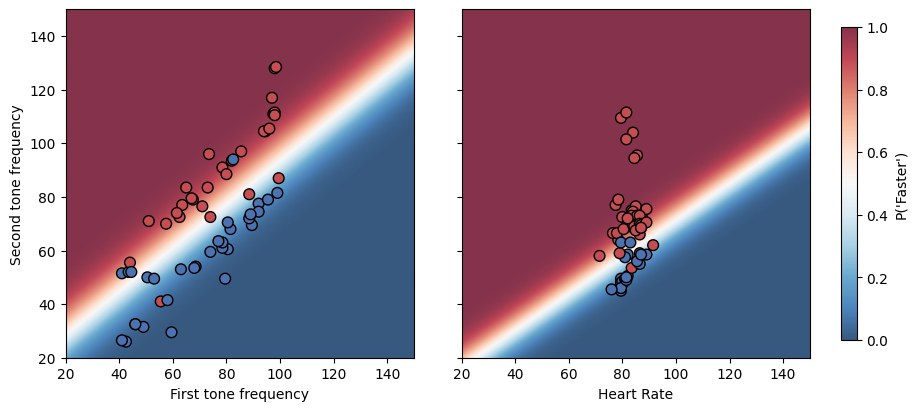

In [48]:
fig, axs = plt.subplots(ncols=2, figsize=(9, 4), sharex=True, sharey=True)

axs[0].imshow(
    extero_decisions_probs.T,
    origin="lower",
    extent=(20.0, 150.0, 20.0, 150.0),
    cmap="RdBu_r",
    interpolation="gaussian",
    alpha=0.8,
)

df = hrd_df[(hrd_df.participant_id == "sub-0049") & (hrd_df.Modality == "Extero")]
axs[0].scatter(
    df.listenBPM.to_numpy(),
    df.responseBPM.to_numpy(),
    edgecolor="k",
    s=60,
    color=["#c44e52" if d == "More" else "#4c72b0" for d in df.Decision.to_numpy()],
)


im = axs[1].imshow(
    intero_decisions_probs.T,
    origin="lower",
    extent=(20.0, 150.0, 20.0, 150.0),
    cmap="RdBu_r",
    interpolation="gaussian",
    alpha=0.8,
)

df = hrd_df[(hrd_df.participant_id == "sub-0049") & (hrd_df.Modality == "Intero")]
axs[1].scatter(
    df.listenBPM.to_numpy(),
    df.responseBPM.to_numpy(),
    edgecolor="k",
    s=60,
    color=["#c44e52" if d == "More" else "#4c72b0" for d in df.Decision.to_numpy()],
)

axs[0].set(xlabel="First tone frequency", ylabel="Second tone frequency")
axs[1].set(xlabel="Heart Rate")

# Add a colorbar spanning all subplots
cbar = fig.colorbar(im, ax=axs, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label("P('Faster')")

Finally, a third way to represent this problem is by examining the implied psychometric functions that guide the final decision, and especially the data that are fed into these functions. In the first case (i.e., people are interoceptors), the x-axis represents the bias of the tone: how much was the frequency increased or decreased from the recorded heart rate? In the second case, the x-axis represents the frequency of the second tone, assuming that the participant only use this value for decision by comparing it to a fixed cardiac belief.

The question we are interested in here is: are people able to use the second model, or are they merely believers?